
# TAREA 1 — Discrete Time Signal Operations

**Fecha:** 2026-09-07  
**Tema (clase de hoy):** Operaciones en señales en tiempo discreto (DT)

> Entrega: **un solo notebook** con tus soluciones y gráficas.



## Relación con **Serie 1 (ejercicios en papel)**

Esta tarea es la **extensión computacional** de la Serie 1.

**Flujo recomendado (por ejercicio):**
1) Resuelve **en papel** (análisis / fórmulas / razonamiento).
2) Implementa aquí para **verificar** con código y gráficas.
3) Si hay contradicción: **debug** hasta entender el error (en el papel o en el código).

### Mapeo rápido (Serie 1 → Notebook)

- **Serie 1 #4** (u[n], δ[n], r[n]) → **Notebook Ejercicio 1**
- **Serie 1 #2** (periodicidad de cos) → **Notebook Ejercicio 2**
- **Serie 1 #5–7** (inversión y corrimientos) → **Notebook Ejercicio 3**
- **Serie 1 #11** (media y RMS) → **Notebook Ejercicio 4**
- **Serie 1 #9** (energía de (0.9)^n u[n]) → **Notebook Ejercicio 5**
- **Serie 1 #12** (auto/cross correlación) → **Notebook Ejercicio 6**



## Reglas (importantes)

- Puedes usar ChatGPT (u otra IA) **solo como verificador**.
- Tu notebook debe incluir tu razonamiento (comentarios) y tu código.
- **No uses atajos** que oculten la idea:
  - `np.roll`, `np.flip`, `x[::-1]` (para inversión), `np.convolve`, `np.correlate`
- Sí puedes usar NumPy básico, `for` loops, y operaciones elementales.

**Pista:** Si tu solución cabe en 1 línea usando una función “mágica”, probablemente no cuenta.


**Clave:** La IA NO sustituye el papel. Úsala para *verificar* y para detectar errores, igual que usarías una calculadora.



## 1) Datos del estudiante

Completa esta celda y vuelve a correrla.


In [1]:

# === Datos del estudiante ===
NOMBRE1 = "Jaramillo Rodriguez Leslie Citlalli"
NUMCUENTA1= "320318931"
GRUPO = "03"
print("Nombre:", NOMBRE1)
print("Numero de cuenta:", NUMCUENTA1)
print("Grupo:", GRUPO)

NOMBRE2 = "López Montero Ivana Abigail"
NUMCUENTA2= "320022027"
print("Nombre:", NOMBRE2)
print("Numero de cuenta:", NUMCUENTA2)
print("Grupo:", GRUPO)

NOMBRE3 = "Salas Hernandez Camila Alexandra"
NUMCUENTA3= "320332815"
print("Nombre:", NOMBRE3)
print("Numero de cuenta:", NUMCUENTA3)
print("Grupo:", GRUPO)

Nombre: Jaramillo Rodriguez Leslie Citlalli
Numero de cuenta: 320318931
Grupo: 03
Nombre: López Montero Ivana Abigail
Numero de cuenta: 320022027
Grupo: 03
Nombre: Salas Hernandez Camila Alexandra
Numero de cuenta: 320332815
Grupo: 03



## 2) Imports y configuración (no modificar)

Esta sección es scaffolding para que no pierdas tiempo con formato de gráficas.


In [2]:

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 3)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)



## 3) (Opcional) Subir foto de tu libreta / sketch

Si dibujas a mano alguna señal, puedes subirla aquí como evidencia.


In [3]:

# (Opcional) En Colab:
# from google.colab import files
# uploaded = files.upload()

# (Opcional) Mostrar una imagen subida (si aplica):
# from PIL import Image
# import io
# fname = list(uploaded.keys())[0]
# img = Image.open(io.BytesIO(uploaded[fname]))
# plt.figure(figsize=(6,4))
# plt.imshow(img); plt.axis("off"); plt.title(fname)
# plt.show()



## 4) Funciones de graficación (scaffold)

Usa estas funciones para graficar de forma consistente.


In [4]:
def stem_plot(n, x, title="", xlabel="n", ylabel="x[n]"):
    """Discrete-time stem plot."""
    n = np.asarray(n)
    x = np.asarray(x)
    markerline, stemlines, baseline = plt.stem(n, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

def compare_stem(n, x1, x2, label1="x1", label2="x2", title=""):
    """Compare two discrete-time signals on the same axes."""
    n = np.asarray(n)
    x1 = np.asarray(x1); x2 = np.asarray(x2)
    plt.stem(n, x1)
    plt.stem(n, x2)
    plt.title(title)
    plt.xlabel("n")
    plt.ylabel("amplitud")
    plt.legend([label1, label2])
    plt.grid(True)
    plt.show()



## 5) Funciones que debes implementar (TODO)

Implementa **sin** usar atajos (`np.roll`, `np.flip`, slicing invertido, etc.).


In [5]:
def time_reverse(x):
    """Return (n_out, x_rev) con x_rev[n] = x[-n], asumiendo que x esta
    indexada en n = 0..N-1 (senal finita).

    Razonamiento:
    Si x[n] existe para n = 0..N-1, entonces x[-n] solo existe cuando
    -n esta en ese mismo rango, es decir cuando n esta en -(N-1)..0.
    Por eso el eje de salida NO es el mismo que el de entrada: hay que
    correrlo. Construimos la senal con un for explicito (sin np.flip
    ni slicing invertido), recorriendo la senal original de atras
    hacia adelante.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    n_out = np.arange(-(N - 1), 1)  # de -(N-1) a 0
    x_rev = np.zeros(N)
    for i in range(N):
        # n_out[i] = -(N-1)+i  =>  x_rev[i] = x[-n_out[i]] = x[(N-1)-i]
        x_rev[i] = x[N - 1 - i]
    return n_out, x_rev


def time_shift(x, k, pad_value=0.0):
    """Return (n_out, y) con y[n] = x[n-k], asumiendo x indexada en
    n = 0..N-1. k > 0 => corrimiento a la DERECHA (retardo).
                k < 0 => corrimiento a la IZQUIERDA (adelanto).

    Razonamiento:
    El soporte original de x va de 0 a N-1. El soporte de x[n-k] va de
    k a k+N-1 (todo se recorre "k" posiciones). Para poder ver la
    senal completa (incluyendo los ceros de padding), generamos un
    eje n_out que cubre la union de ambos soportes y llenamos cada
    muestra con un for explicito, revisando si el indice original
    cae dentro de rango.
    """
    x = np.asarray(x, dtype=float)
    N = len(x)
    n_min = min(0, k)
    n_max = max(N - 1, k + N - 1)
    n_out = np.arange(n_min, n_max + 1)
    y = np.zeros(len(n_out))
    for i in range(len(n_out)):
        n = n_out[i]
        m = n - k  # indice que hay que consultar en la x original
        if 0 <= m < N:
            y[i] = x[m]
        else:
            y[i] = pad_value
    return n_out, y


def energy(x):
    """E = sum |x[n]|^2 para las muestras disponibles.
    Razonaiento:
    La energía es solo sumar el cuadrado de cada muestra (|x[n]|^2).
    Entonces convertimos la señal a floats para no tener problemas de
    precisión, luego inicializamos un acumulador en 0 y recorremos la
    señal con un for sumando cada valor al cuadrado.
    El total que queda al final es la energía de la señal.
    """
    x = np.asarray(x, dtype=float)
    total = 0.0
    for val in x:
        total += val ** 2
    return total


def mean_value(x):
    """Media (valor promedio) sobre las muestras disponibles.
    Razonamiento:
    Sacamos el promedio normal (el nivel DC de la señal), es dedcir
    sumar todas las muestras y dividir entre cuántas son.
    Por lo que, usamos un for para ir sumando cada muestra directa en
    un acumulador y al final dividimos esa suma total entre el tamaño
    del arreglo (len(x)).
    """
    x = np.asarray(x, dtype=float)
    total = 0.0
    for val in x:
        total += val
    return total / len(x)


def rms(x):
    """RMS = sqrt( media( x[n]^2 ) ) sobre las muestras disponibles.
    El RMS se obtiene a partir de elevando cda muestra al cuadro, sumando todos
    los valores y dividiendo entre el numero de muestras para asi obtener la media.
    Para despues calcular la raiz cuadrada del resultado. Para esto se uso un for
    para recorrer cada muestra, y asu acumular su cuadrado y al final calculamos la raiz
    cuadrada del promedio."""
    x = np.asarray(x, dtype=float)
    total = 0.0
    for val in x:
        total += val ** 2
    return np.sqrt(total / len(x))


def autocorr(x):
    """Autocorrelacion r_xx[k] = sum_n x[n]*x[n-k], para k = -(N-1)..(N-1).
    La autocorrelacion compara la señal con ella misma para diferentes corrimeintos k.
    Entonces para cada valor k, recorremos las muestras de x y buscamos la muestra correspoendiente
    x[n-k]. Por lo que si el indice esta dentro del rango de la señal,
    multiplicamos ambas muestras y calculamos el resultado. Y asi guardamos esa suma
    para cada valor k."""
    x = np.asarray(x, dtype=float)
    N = len(x)
    k_vals = np.arange(-(N - 1), N)
    rxx = np.zeros(len(k_vals))
    for idx in range(len(k_vals)):
        k = k_vals[idx]
        s = 0.0
        for n in range(N):
            m = n - k
            if 0 <= m < N:
                s += x[n] * x[m]
        rxx[idx] = s
    return k_vals, rxx

def crosscorr(x, y):
    """Correlación cruzada r_xy[k] = sum_n x[n+k]*y[n] , para k = -(N-1)..(N-1).
    Aqui se comparan dos señales diferentes para distintos corrimientos k.
    Primero se verifica que ambas señales tengan la misma longitud. Y asi para cada valor
    de k, recorremos las muestras de x y buscamos la muestra correspoendiente de x[n+k].
    Entomces si el indice esta dentro del rango, multiplicamos las dos muestras y
    acumulamos el resultado. Y asi obtenemos la correlacion para cada corriemiento."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    N = len(x)
    assert len(y) == N
    k_vals = np.arange(-(N - 1), N)
    rxy = np.zeros(len(k_vals))
    for idx in range(len(k_vals)):
        k = k_vals[idx]
        s = 0.0
        for n in range(N):
            m = n + k
            if 0 <= m < N:
                s += x[m] * y[n]
        rxy[idx] = s
    return k_vals, rxy


## 6) Ejercicios

En cada ejercicio:
1) escribe tu razonamiento en comentarios,
2) implementa,
3) grafica y verifica visualmente.


###6.1) Ejercicio 1
1. For each of the following signals, determine whether it is continuous/discrete, periodic/aperiodic, and causal/non-causal:
   a) x(t) = sin(2π10t)
   b) x[n] = u[n-3]
   c) x(t) = e-tu(t)


**Serie 1 #1**

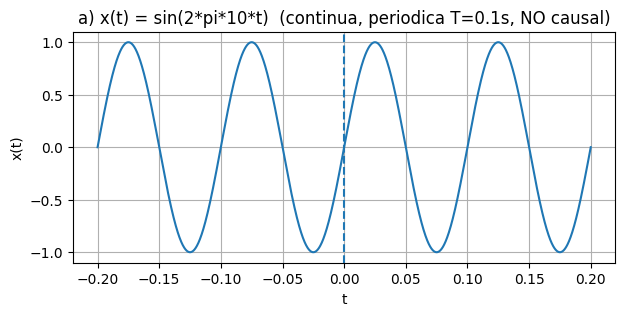

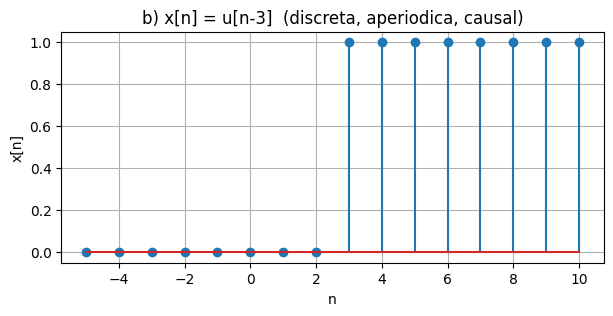

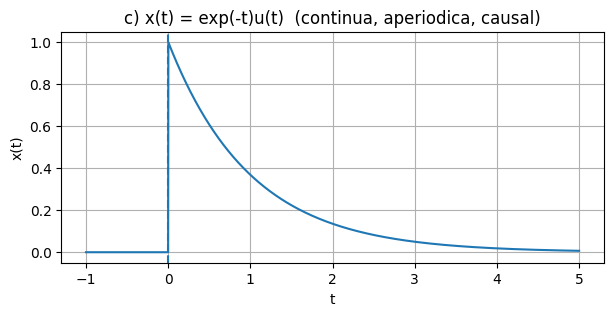

a) sin(2*pi*10*t) : continua, periodica (T=0.1s), NO causal
b) u[n-3]         : discreta, aperiodica, causal
c) exp(-t)u(t)    : continua, aperiodica, causal


In [6]:
"""
Razonamiento:
Abordamos cada señal distinguiendo primero si correspondía a tiempo continuo o
discreto. Para las continuas generamos una base temporal fina con np.linspace
y graficamos con plt.plot: la senoidal la evaluamos de forma directa para
observar sus oscilaciones periódicas cada 0.1s y verificar que no
es causal al tener valores antes de cero, mientras que a la exponencial le
aplicamos una condición para anularla en tiempos negativos, simulando el efecto
de u(t) y volviéndola causal y aperiódica. En cuanto a la discreta, definimos
un eje entero n y construimos el escalón desplazado u[n-3] asignando el valor
1 únicamente a partir de la muestra 3, utilizando stem_plot para reflejar el
comportamiento discreto, causal y sin repetición periódica.
"""

# ---------------------------------------------------------------
# a) x(t) = sin(2*pi*10*t)   (tiempo continuo -> lo simulamos con
#    un muestreo muy fino, solo para poder graficarlo)
t = np.linspace(-0.2, 0.2, 2000)
x_a = np.sin(2*np.pi*10*t)

plt.figure()
plt.plot(t, x_a)
plt.axvline(0, linestyle='--')
plt.title("a) x(t) = sin(2*pi*10*t)  (continua, periodica T=0.1s, NO causal)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

# ---------------------------------------------------------------
# b) x[n] = u[n-3]   (tiempo discreto)
n = np.arange(-5, 11)
x_b = np.array([1.0 if ni >= 3 else 0.0 for ni in n])
stem_plot(n, x_b, title="b) x[n] = u[n-3]  (discreta, aperiodica, causal)")

# ---------------------------------------------------------------
# c) x(t) = exp(-t) * u(t)   (tiempo continuo)
t2 = np.linspace(-1, 5, 2000)
x_c = np.array([np.exp(-ti) if ti >= 0 else 0.0 for ti in t2])

plt.figure()
plt.plot(t2, x_c)
plt.axvline(0, linestyle='--')
plt.title("c) x(t) = exp(-t)u(t)  (continua, aperiodica, causal)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)
plt.show()

print("a) sin(2*pi*10*t) : continua, periodica (T=0.1s), NO causal")
print("b) u[n-3]         : discreta, aperiodica, causal")
print("c) exp(-t)u(t)    : continua, aperiodica, causal")

###6.2) Ejercicio 2
Periodicidad de x[n] = cos((5π/6)n)

1) Determina si es periódica.  
2) Si lo es, encuentra su **periodo fundamental** N0.

**TODO:** explica en texto (markdown o comentarios) y verifica con una gráfica de varios periodos.

**Serie 1 #2** (periodicidad de cos(·)).

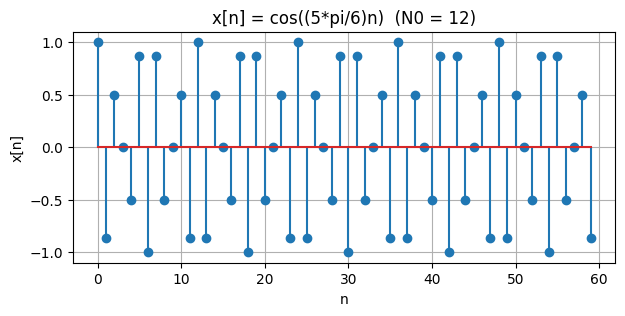

x[0:12]     = [ 1.    -0.866  0.5    0.    -0.5    0.866 -1.     0.866 -0.5    0.
  0.5   -0.866]
x[12:24]    = [ 1.    -0.866  0.5   -0.    -0.5    0.866 -1.     0.866 -0.5    0.
  0.5   -0.866]
Coinciden?  True


In [7]:
"""La señal x[n] = cos((5*pi/6)n) es una señal discreta que puede ser
periodica si la frecuencis angular w0 se divide entre 2*pi y su resultado
da un numero racional

Primero creamos muestras suficientes para poder observar como se repite
la señal.
Luego se calcula cada muestra de x[n] usando x[n] = cos((5*pi/6)n).
Ya sabemos que el periodo fundamental es N0 = 12, entonces la señal debe de repertirse
cada 12 muestras. Por eso graficamos la señal completa y despues comparamos las
primeras 12 muestras con las siguientes 12.

Y por ultimo usamos np.allclose para comprobar si los dos bloques son iguales.
Si devuelve True, significa que x[0:12] y x[12:24] son iguales y entomces la señal
es periodica con periodo 12."""

n = np.arange(0, 60)
x = np.cos((5*np.pi/6)*n)
stem_plot(n, x, title="x[n] = cos((5*pi/6)n)  (N0 = 12)")

print("x[0:12]     =", x[0:12])
print("x[12:24]    =", x[12:24])
print("Coinciden? ", np.allclose(x[0:12], x[12:24]))


###6.3) Ejercicio 3 - Señales básicas

Para **-5 ≤ n ≤ 5**, construye y grafica:
- a) u[n]
- b) δ[n]
- c) r[n] = n u[n]

**TODO:** crea `n`, `u`, `delta`, `r` y grafícalas con `stem_plot`.

**Serie 1 #4** (u[n], δ[n], r[n]).

n     : [-5 -4 -3 -2 -1  0  1  2  3  4  5]
u[n]  : [0 0 0 0 0 1 1 1 1 1 1]
delta : [0 0 0 0 0 1 0 0 0 0 0]
r[n]  : [0 0 0 0 0 0 1 2 3 4 5]


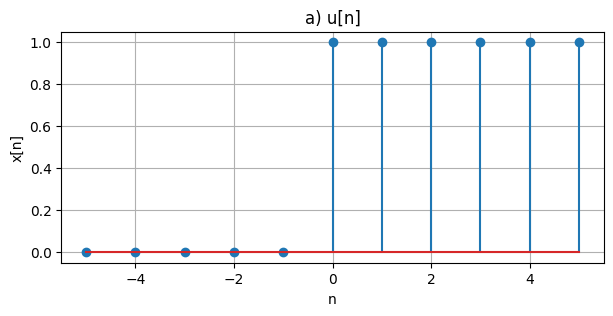

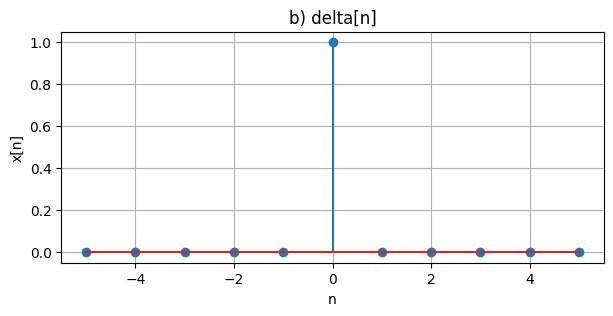

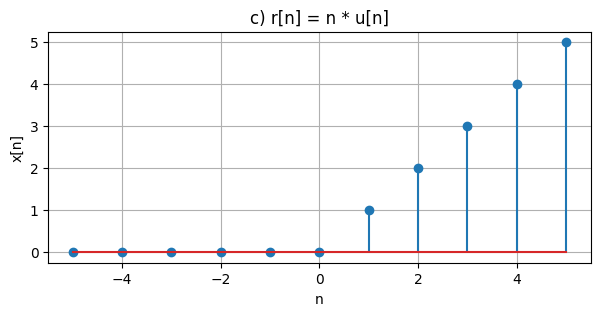

In [8]:
"""
Razonamiento:
Creamos un eje común 'n' que sera temporal, el cual ira de -5 hasta 5 para
graficar todo junto.
Luego evaluamos muestra por muestra según la regla de cada señal:
- Para u[n]: Es el escalón, así que se "enciende" en 1 desde el origen
(n >= 0) y hacia atrás se queda en 0.
- Para delta[n]: Es el impulso, así que solo existe en el 0 con valor 1, y
en cualquier otro lado vale 0.
- Para r[n]: Es la rampa (n * u[n]), lo que significa que antes de 0 vale 0
(por el escalón) y a partir de 0 va creciendo tomando exactamente el mismo
valor de su índice 'n'.
"""
# u[n] = 1 para n>=0, 0 para n<0
# delta[n] = 1 para n==0, 0 para otro caso
# r[n] = n*u[n]  (rampa: vale n para n>=0, y 0 para n<0)

# Declaramos el eje n de -5 a 5
n = np.arange(-5, 6)

# u[n]: Vale 1 si n >= 0, y 0 si n < 0
u = np.zeros(len(n), dtype=int)
for i in range(len(n)):
    if n[i] >= 0:
        u[i] = 1

# delta[n]: Solo vale 1 en n == 0, y 0 en cualquier otro valor
delta = np.zeros(len(n), dtype=int)
for i in range(len(n)):
    if n[i] == 0:
        delta[i] = 1

# r[n] = Multiplica el valor del tiempo por el escalón en esa posición
r = np.zeros(len(n), dtype=int)
for i in range(len(n)):
    r[i] = n[i] * u[i]

print("n     :", n)
print("u[n]  :", u)
print("delta :", delta)
print("r[n]  :", r)

# Graficar señales resultantes
stem_plot(n, u, title="a) u[n]")
stem_plot(n, delta, title="b) delta[n]")
stem_plot(n, r, title="c) r[n] = n * u[n]")


###6.4) Ejercicio 4 - Transformaciones en una secuencia finita

Dada: **x[n] = {1,2,3,4}** para n = 0,1,2,3

Calcula y grafica:
- a) x[-n]
- b) x[n-2]
- c) x[n+1]
- d) x[-n+2]
- e) x[3-n]

**Nota:** Define claramente tu eje n para cada resultado (con padding si hace falta).

**Serie 1 #5-7** (x[-n], x[n±k], composiciones).

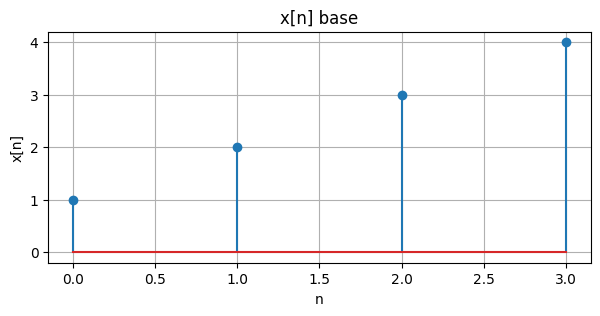

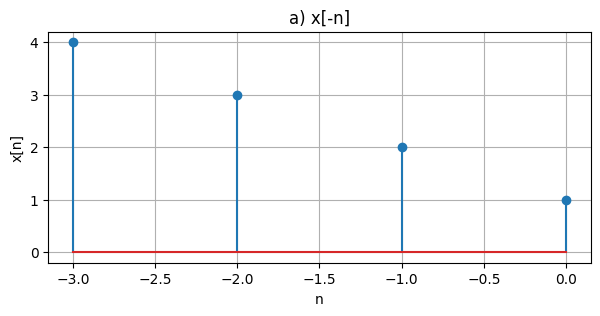

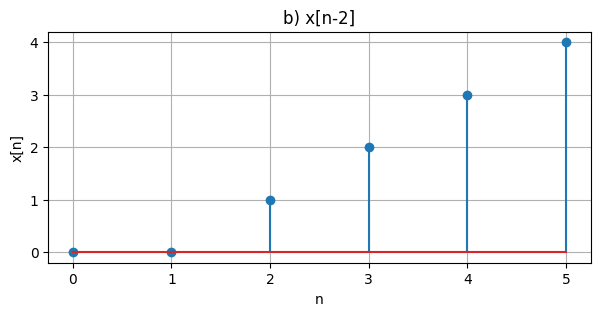

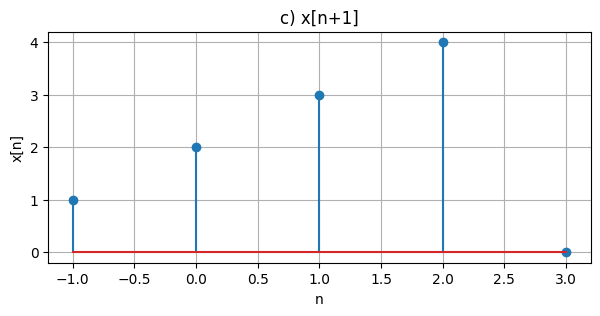

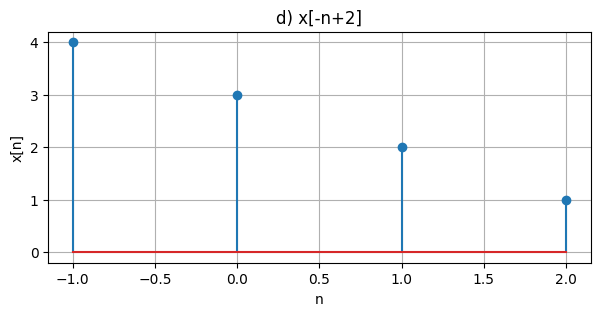

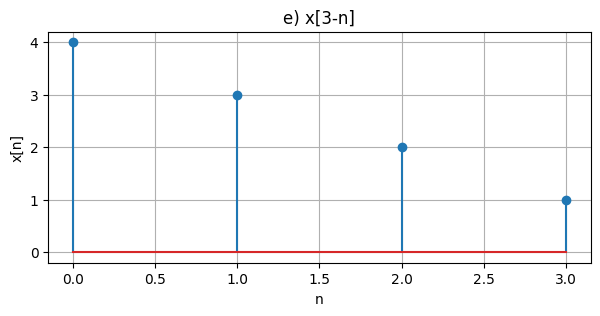

a) x[-n]     : n = [-3 -2 -1  0]  x = [4. 3. 2. 1.]
b) x[n-2]    : n = [0 1 2 3 4 5]  x = [0. 0. 1. 2. 3. 4.]
c) x[n+1]    : n = [-1  0  1  2  3]  x = [1. 2. 3. 4. 0.]
d) x[-n+2]   : n = [-1  0  1  2]  x = [4. 3. 2. 1.]
e) x[3-n]    : n = [0 1 2 3]  x = [4. 3. 2. 1.]


In [9]:
""" Razonamiento:
Para la inversión de señales usamos directamente la función time_reverse(x)
que devuelve la función invertida. Para el desplazamiento de señales usamos
directamente la función time_shift(x, k, pad_value=0.0) que devuelve la señal
adelantada o retrasada n posiciones, incluyendo padding en caso de ser necesario.
Para los incisos d y e que requieren combinación de transformaciones, primero
adelantamos la señal y luego la invertimos."""

# Señal base
x = np.array([1,2,3,4], dtype=float)
n = np.arange(0, len(x))

stem_plot(n, x, title="x[n] base")

# a) x[-n]
#    Usamos time_reverse directamente para invertir la señal
n_rev, x_rev = time_reverse(x)
stem_plot(n_rev, x_rev, title="a) x[-n]")

# b) x[n-2]
#    Usamos time_shift para hacer un retardo de 2
n_delay2, x_delay2 = time_shift(x, 2)
stem_plot(n_delay2, x_delay2, title="b) x[n-2]")

# c) x[n+1]
#    Usamos time_shift para hacer un adelanto de 1
n_adv1, x_adv1 = time_shift(x, -1)
stem_plot(n_adv1, x_adv1, title="c) x[n+1]")

# d) x[-n+2]
n_d_shift, x_d_shift = time_shift(x, -2)              # Primero adelantamos la señal 2 posiciones
x_d_shift = x_d_shift[x_d_shift != 0]                 # Quitamos el padding que se agregó al hacer el adelanto
n_d_rev, x_minus_n_plus_2 = time_reverse(x_d_shift)   # Ahora invertimos la señal
n_d = np.arange(-1, 3)                                # El eje final va de -1 a 2, ya que x[-n + 2] existe cuando 0 <= -n + 2 <= 3
stem_plot(n_d, x_minus_n_plus_2, title="d) x[-n+2]")

# e) x[3-n]
n_e_shift, x_e_shift = time_shift(x, -3)              # Primero adelantamos la señal 3 posiciones
x_e_shift = x_e_shift[x_e_shift != 0]                 # Quitamos el padding que se agregó al hacer el adelanto
n_e_rev, x_3_minus_n = time_reverse(x_e_shift)        # Ahora invertimos la señal
n_e = np.arange(0, 4)                                 # El eje final va de 0 a 3, ya que x[3-n] existe cuando 0 <= 3-n <= 3
stem_plot(n_e, x_3_minus_n, title="e) x[3-n]")

print("a) x[-n]     : n =", n_rev, " x =", x_rev)
print("b) x[n-2]    : n =", n_delay2,  " x =", x_delay2)
print("c) x[n+1]    : n =", n_adv1,  " x =", x_adv1)
print("d) x[-n+2]   : n =", n_d,   " x =", x_minus_n_plus_2)
print("e) x[3-n]    : n =", n_e,   " x =", x_3_minus_n)

###6.5) Ejercicio 5 — Energía (señal exponencial DT truncada)

Define una señal finita:
x[n] = (0.9)^n u[n]  para n = 0..30

1) Grafica x[n]  
2) Calcula la energía aproximada en ese intervalo (truncado)  
3) Explica qué pasaría si el intervalo fuera infinito (conceptual)

**TODO:** usa `energy(x)` y discute.

**Serie 1 #9** (energía de (0.9)^n u[n]).

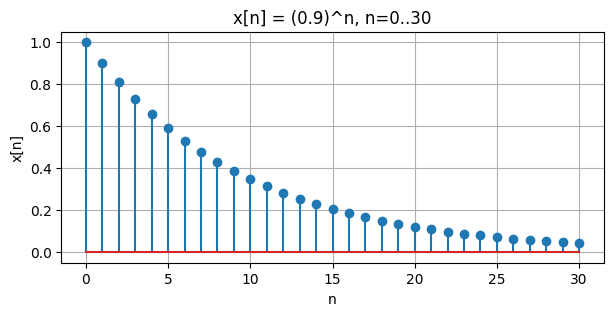

Energia (truncada 0..30): 5.255496956089839
Energia teorica si n fuera hasta infinito: 5.263157894736843
Diferencia con la truncada (0..30): 0.007660938647004123


In [10]:
"""
Razonamiento
Se tiene la señal x[n] = (0.9)^n, y podemos observar en la grafica
que comienza en 1 y conforme aumenta el valor de n, la amplitud va disminuyendo
y se va acercando cada vez mas a cero.
Aunque la señal nunca llega exactamente a cero, no significa que se energia
sea infinita. Para comprobar esto calculamos la energia que consiste en sumar el
cuadrado de todas las muestras.

Si consideramos la señal hasta infinito, obtenemos una serie geometrica con razon
0.81, como es menor que 1, la serie converge y obtenemos una energia finita.

Ademas al comparar la energia de las primeras 31 muestras con la energia teorica
hasta infinito, podemos ver que la diferencia es muy pequeña, entonces esto
significa que esas 31 muestras ya contienen toda la energia de la señal.
Por lo que podemos concluir que x[n] = (0.9)^(n)u[n] es una señal de energia
finita porque su energia total converge a un valor finito.

"""

n = np.arange(0, 31)
x = (0.9**n)

stem_plot(n, x, title="x[n] = (0.9)^n, n=0..30")

E = energy(x)
print("Energia (truncada 0..30):", E)

print("Energia teorica si n fuera hasta infinito:", 1/(1-0.81))
print("Diferencia con la truncada (0..30):", 1/(1-0.81) - E)




###6.6) Ejercicio 6 - Energía, media y RMS

Para x[n] = {2, -2, 2, -2} (n=0..3):

1) Calcula la **media**  
2) Calcula el **RMS**  
3) Interpreta: ¿media = 0 implica RMS = 0? (explica)

**TODO:** Implementa usando tus funciones `mean_value` y `rms`.

**Serie 1 #11** (media y RMS).

In [11]:
"""
Razonamiento:
Definimos la señal como arreglo para calcular sus valores con las funciones
que armamos. Al sacar la media da 0 porque los valores positivos y negativos
valen lo mismo (2 y -2), así que al sumarlos se anulan, mostrando que la señal
no tiene componente de directa (DC). En cambio, para el RMS cada muestra se
eleva primero al cuadrado antes de promediar, lo que desaparece los signos
negativos y deja puro valor positivo ($4$ en cada término), dando una raíz
final de 2.0. Con esto la media igual a cero no significa RMS igual a cero:
la media solo ve el balance promedio de los signos,  mientras que el RMS mide
la energía real con la que oscila la señal.
"""
x = np.array([2, -2, 2, -2], dtype=float)

m = mean_value(x)
r = rms(x)
print("Media:", m)
print("RMS:", r)


Media: 0.0
RMS: 2.0


###6.7) Ejercicio 7 - Correlación (sin funciones mágicas)

x[n] = {1,2,1}  
y[n] = {1,0,-1}

1) Calcula la **autocorrelación** r_xx[k]  
2) Calcula la **correlación cruzada** r_xy[k]  
3) Grafica r_xx[k] y r_xy[k] con eje de lags k.

**TODO:** implementa `autocorr` y `crosscorr` usando loops e índices.

**Serie 1 #12** (autocorrelación y correlación cruzada).

k     : [-2 -1  0  1  2]
r_xx  : [1. 4. 6. 4. 1.]


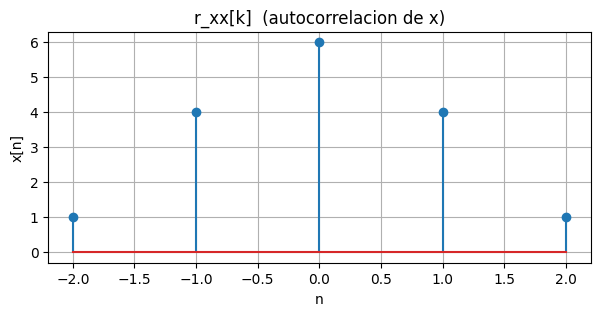

k     : [-2 -1  0  1  2]
r_xy  : [-1. -2.  0.  2.  1.]


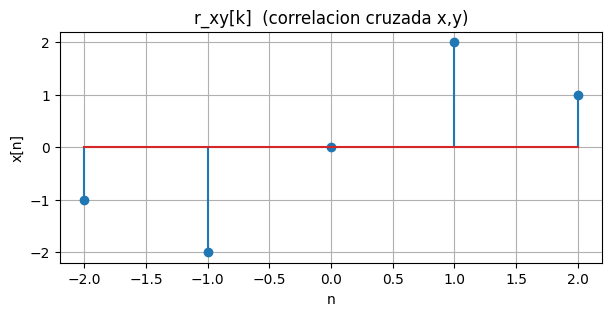

Chequeo r_xx[0] == energy(x): 6.0 == 6.0


In [12]:
"""Razonamiento:
Para calcular la autocorrelación y la correlación cruzada implementamos las
funciones previamente codificadas. Para cada desplazamiento k, se recorren las
muestras de las señales y se calcula el índice m = n+k, que representa la
muestra desplazada de x. Si el índice se encuentra dentro del rango válido, se
multiplican las muestras correspondientes y se acumulan los resultados. En la
autocorrelación se utiliza la misma señal, siguiendo r_xx[k] = sum x[n+k]*x[n],
mientras que en la correlación cruzada se comparan las señales x y y mediante
r_xy[k] = sum x[n+k]*y[n]."""

x = np.array([1,2,1], dtype=float)
y = np.array([1,0,-1], dtype=float)

k, rxx = autocorr(x)
print("k     :", k)
print("r_xx  :", rxx)
stem_plot(k, rxx, title="r_xx[k]  (autocorrelacion de x)")

k, rxy = crosscorr(x, y)
print("k     :", k)
print("r_xy  :", rxy)
stem_plot(k, rxy, title="r_xy[k]  (correlacion cruzada x,y)")

# Observaciones:
# - r_xx[k] es SIMETRICA (r_xx[k] = r_xx[-k]): [1,4,6,4,1]. Esto
#   siempre pasa con la autocorrelacion de una senal real.
# - r_xx[0] = 6 es el valor MAXIMO y coincide con la energia de x
#   (energy(x) = 1^2+2^2+1^2 = 6): la autocorrelacion en k=0 siempre
#   da la energia de la senal.
# - r_xy[k] NO es simetrica en general, porque x y y son senales
#   distintas.
print("Chequeo r_xx[0] == energy(x):", rxx[len(rxx)//2], "==", energy(x))



## 🔊 Sección Audio (extensión opcional)

**Idea:** Graba audio (con tu celular, Audacity, etc.), guarda un `.wav` y súbelo al notebook.

- En **Colab**: usa `files.upload()` (celda siguiente).
- En **Jupyter local**: coloca el `.wav` en la misma carpeta del notebook y pon el nombre en `wav_path`.

> Esta sección es para experimentar con **señales reales** usando las mismas operaciones DT.


In [13]:

# === (Colab) Subir WAV (MISMO PATRÓN DEL EJEMPLO) ===
from google.colab import files
uploaded = files.upload()  # elige tu archivo .wav

# TODO: escribe EXACTAMENTE el nombre del archivo que subiste (tal como aparece arriba)
wav_path = "audio_tarea1.wav"

print("Usando wav_path =", wav_path)


Saving audio_tarea1.wav to audio_tarea1.wav
Usando wav_path = audio_tarea1.wav


In [14]:

# === Cargar WAV (se mantiene simple y robusto) ===
# Intentamos soundfile primero; si no está, usamos scipy.io.wavfile.
fs = None
audio = None

audio_loaded = False

try:
    import soundfile as sf
    audio, fs = sf.read(wav_path, dtype="float32", always_2d=False)

    # Si es estéreo (2+ canales), audio llega con forma (N, canales).
    # stem_plot necesita una señal 1-D, así que nos quedamos con un
    # solo canal (el primero).
    if hasattr(audio, "ndim") and audio.ndim > 1:
        audio = audio[:, 0]

    audio_loaded = True
except Exception as e:
    print("soundfile falló o no está instalado:", e)

if not audio_loaded:
    try:
        from scipy.io import wavfile
        fs, audio_int = wavfile.read(wav_path)

        # Si es estéreo, toma un canal (puedes cambiarlo)
        if hasattr(audio_int, "ndim") and audio_int.ndim > 1:
            audio_int = audio_int[:, 0]

        # Normaliza a float32 en [-1, 1] si viene en entero
        if np.issubdtype(audio_int.dtype, np.integer):
            max_val = np.iinfo(audio_int.dtype).max
            audio = audio_int.astype("float32") / max_val
        else:
            audio = audio_int.astype("float32")

        audio_loaded = True
    except Exception as e:
        print("No pude cargar el WAV con scipy tampoco:", e)

if audio_loaded:
    print("fs =", fs, "Hz")
    print("muestras =", len(audio))

fs = 48000 Hz
muestras = 271296


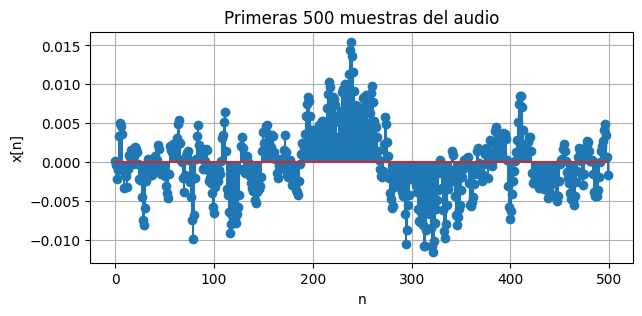

In [15]:

# === Visualización (muestra corta) ===
# Graficamos solo las primeras N muestras para que se vea tipo DT.
N = 500  # puedes cambiar
if audio is not None:
    n = np.arange(len(audio))
    stem_plot(n[:N], audio[:N], title=f"Primeras {N} muestras del audio")


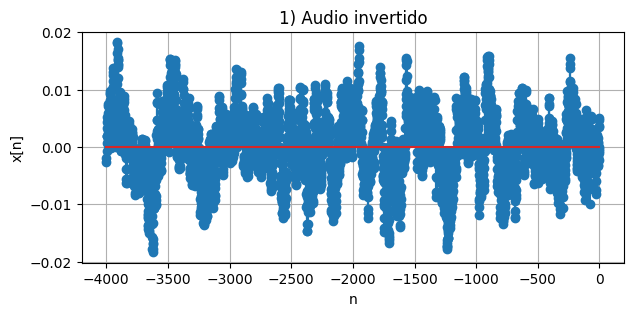

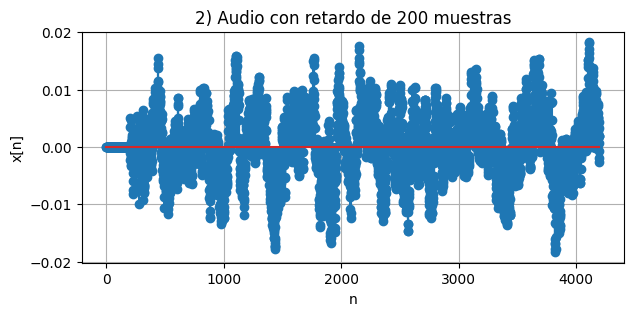

Energía original: 0.13894353061914444
Energía después del corrimiento: 0.13894353061914444


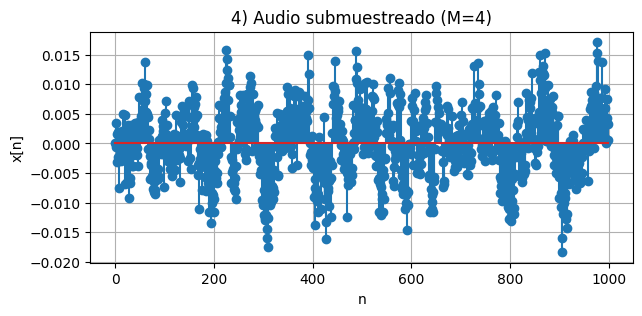

In [16]:

# === Experimentos sugeridos (TODO) ===

# Nota: Para no hacer señales enormes, trabaja con una ventana:
# audio_w = audio[:4000]

# TODO: implementa aquí tus pruebas y gráficas

audio_w = audio[:4000]

# 1) Invertir: usa time_reverse(audio_short) sobre una ventana corta (ej. primeras 2000 muestras)
n_inv, audio_inv = time_reverse(audio_w)
stem_plot(n_inv, audio_inv, title="1) Audio invertido")

# 2) Corrimiento: aplica time_shift(..., k=200) (retardo) o k=-200 (adelanto)
n_shift, audio_shift = time_shift(audio_w, 200)
stem_plot(n_shift, audio_shift, title="2) Audio con retardo de 200 muestras")

# 3) Energía: compara energy(x) antes/después (¿cambia? ¿por qué?)
#    Calculamos la energía antes y después del corrimiento.
#    La energía debe mantenerse igual porque el corrimiento solo cambia la posición de las muestras y no sus valores
energia_original = energy(audio_w)
energia_shift = energy(audio_shift)
print("Energía original:", energia_original)
print("Energía después del corrimiento:", energia_shift)


# 4) Submuestreo manual: crea x_ds = audio[::M] (aquí SÍ se permite slicing por submuestreo)
M = 4
audio_ds = audio_w[::M]
n_ds = np.arange(len(audio_ds))
stem_plot(n_ds, audio_ds, title=f"4) Audio submuestreado (M={M})")



## 7) IA (requerido)

Para **al menos 3 ejercicios**, incluye:

1) Tu solución manual/código  
2) El prompt exacto que usaste con IA  
3) Una comparación breve: ¿en qué coincide y en qué no? ¿por qué?

> Objetivo: aprender a **verificar**, no a copiar.


### 7.1) Ejercicio 1 (IA)

###Prompt utilizado (Gemini):
Resuelve el siguiente ejercicio en Python/NumPy sin usar funciones automáticas ni atajos prohibidos (np.roll, np.flip, [::-1], np.convolve, np.correlate).Ejercicio:Para el rango temporal $-5 \le n \le 5$, define y grafica con stem_plot:El escalón unitario $u[n]$El impulso unitario $\delta[n]$La rampa unitaria $r[n] = n \cdot u[n]$


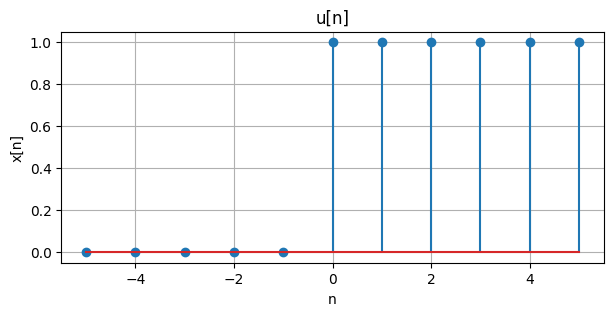

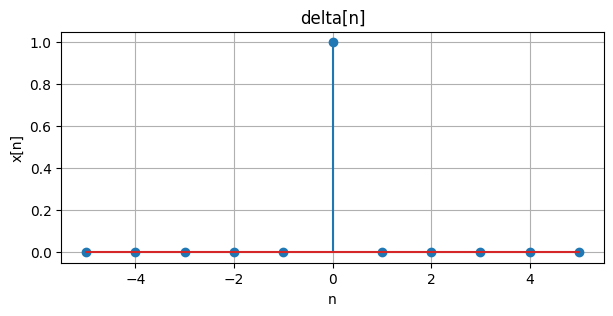

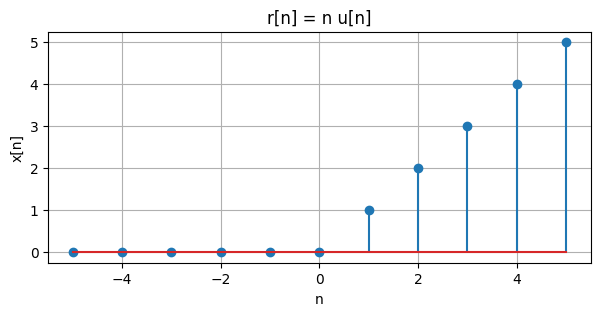

In [17]:
import numpy as np

# Definición del eje de tiempo discreto en el intervalo [-5, 5]
n = np.arange(-5, 6)

# a) Señal escalón unitario u[n]
# Retorna 1.0 para valores de n mayores o iguales a 0; de lo contrario, 0.0
u = np.array([1.0 if ni >= 0 else 0.0 for ni in n])

# b) Señal impulso unitario delta[n] (Delta de Kronecker)
# Retorna 1.0 únicamente en el origen (n == 0) y 0.0 en cualquier otro valor
delta = np.array([1.0 if ni == 0 else 0.0 for ni in n])

# c) Señal rampa unitaria r[n] = n * u[n]
# Toma el valor de n para n >= 0 y se anula para muestras negativas
r = np.array([ni if ni >= 0 else 0.0 for ni in n])

# Graficación de las señales discretas mediante gráficos de tallo
stem_plot(n, u, title="u[n]")
stem_plot(n, delta, title="delta[n]")
stem_plot(n, r, title="r[n] = n u[n]")


### Comparación entre soluciones

Para este ejercicio 1, , ambas soluciones dan exactamente los mismos resultados y gráficas, pero la forma de programarlo cambia, principalmente porque la IA proponía poner todo en una sola línea por señal usando comprensión de listas con condicionales rápidos. Sin embargo, en nuestro código preferimos hacerlo más a mano y paso a paso, por lo que creamos los arreglos con ceros usando np.zeros y metimos ciclos for con if para ir checando muestra por muestra cuándo 'encender' el escalón o el impulso, y en la rampa multiplicamos directamente el tiempo por el escalón

###7.2) Ejercicio 2 (IA)

###Prompt utilizado (Gemini):

Resuelve el siguiente ejercicio en Python, sin usar np.roll, np.flip, [::-1], np.convolve, np.correlate.

Ejercicio 2 — Periodicidad de x[n] = cos((5π/6)n)
1. Determina si es periódica.
2. Si lo es, encuentra su **periodo fundamental** N0.

**TODO:** explica en texto (markdown o comentarios) y verifica con una gráfica de varios periodos.

¿Cumple x[n] == x[n + 12] en todo el rango?: True


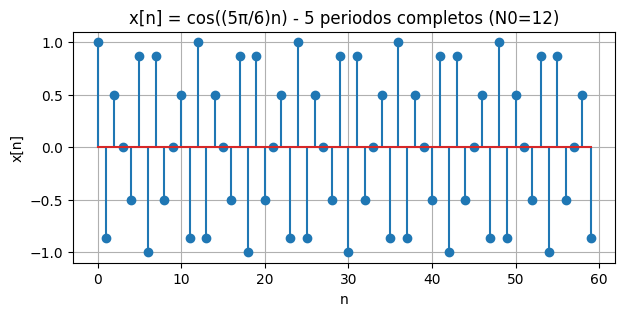

In [18]:
# RAZONAMIENTO:
# Para w0 = 5pi/6, evaluamos (w0 / 2pi) = (5pi/6) / (2pi) = 5/12.
# Como 5/12 es un número racional irreducible (m=5, N0=12),
# la señal ES PERIÓDICA con periodo fundamental N0 = 12 muestras.

n = np.arange(0, 60)
x = np.cos((5 * np.pi / 6) * n)

# Verificación de que x[n] == x[n + 12] usando resta desplazada
es_periodica = np.allclose(x[12:], x[:-12])
print("¿Cumple x[n] == x[n + 12] en todo el rango?:", es_periodica)

stem_plot(n, x, title="x[n] = cos((5π/6)n) - 5 periodos completos (N0=12)")

##Comparacion entre soluciones

Para este ejercicio tanto el de nosotras como el de la IA nos da el mismo resultado pero la forma de resolverlo es diferente. En nuestra forma comparamos las primeras 12 muestras contra el segundo bloque.El del IA hace una resta vectorial evaluando la condicion x[n] = x[n+12] para todas las muestras del arreglo de forma simultanea.

### 7.3) Ejercicio 3 (IA)

###Prompt utilizado (Chat GPT):

Con base en las instrucciones de la tarea, realiza el código para resolver los ejercicios de transformación de señales discretas. Ten en cuenta que ya existen las funciones time_reverse (devuelve la señal invertida) y time_shift (devuelve la señal desplazada)

### Solución con IA

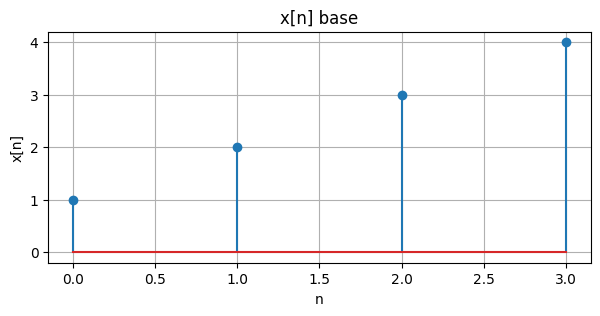

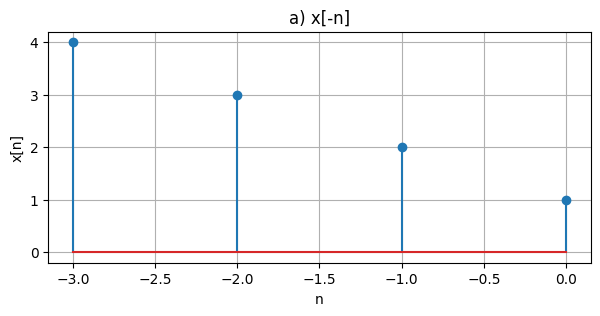

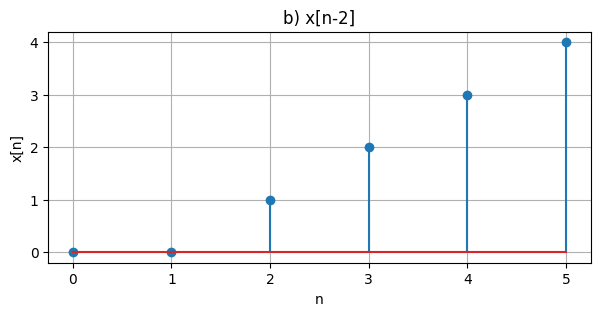

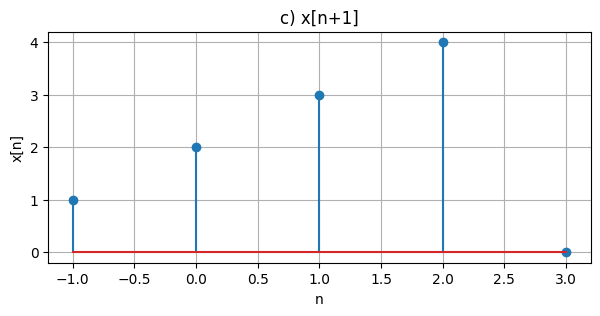

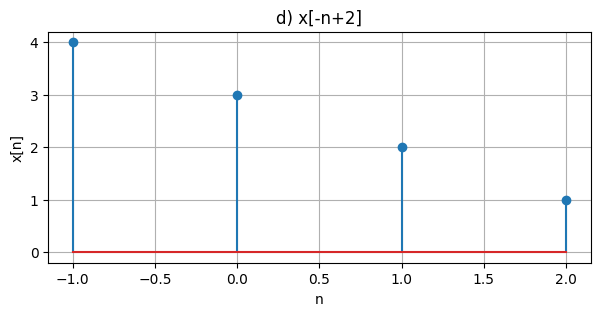

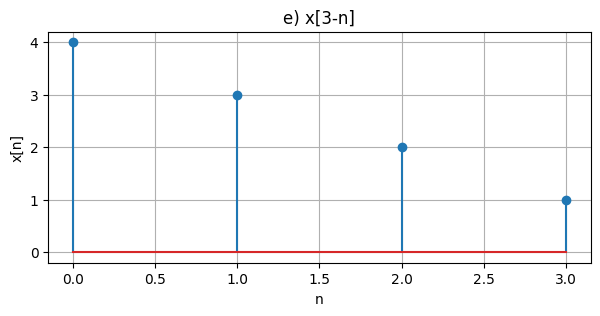

In [19]:
# Señal base
x = np.array([1,2,3,4], dtype=float)
n = np.arange(0, len(x))

stem_plot(n, x, title="x[n] base")

# a) x[-n]
#    Se hace la inversión temporal
n_a, x_minus_n = time_reverse(x)
stem_plot(n_a, x_minus_n, title="a) x[-n]")

# b) x[n-2]
#    Se desplaza la señal 2 posiciones hacia la derecha.
n_b, x_n_minus_2 = time_shift(x, 2)
stem_plot(n_b, x_n_minus_2, title="b) x[n-2]")

# c) x[n+1]
#    Se adelanta la señal 1 posición.
n_c, x_n_plus_1 = time_shift(x, -1)
stem_plot(n_c, x_n_plus_1, title="c) x[n+1]")

# d) x[-n+2]
#    y[n] = x[-n + 2] solo existe cuando 0 <= -n + 2 <= 3, es decir -1 <= n <= 2.
#    Recorremos ese eje con un for y para cada n consultamos si el indice (-n + 2) está dentro de x.
#    De ser así, obtenemos su valor correspondiente.
n_d = np.arange(-1, 3)
x_minus_n_plus_2 = np.zeros(len(n_d))
for i in range(len(n_d)):
    idx = - n_d[i] + 2
    if 0 <= idx < len(x):
        x_minus_n_plus_2[i] = x[int(idx)]
stem_plot(n_d, x_minus_n_plus_2, title="d) x[-n+2]")

# e) x[3-n]
#    y[n] = x[3-n] existe cuando 0 <= 3-n <= 3, es decir 0 <= n <= 3.
#    Recorremos ese eje con un for y para cada n consultamos si el indice (3 - n) está dentro de los índices de x.
#    De ser así, obtenemos su valor correspondiente.
n_e = np.arange(0, 4)
x_3_minus_n = np.zeros(len(n_e))
for i in range(len(n_e)):
    idx = 3 - n_e[i]
    if 0 <= idx < len(x):
        x_3_minus_n[i] = x[int(idx)]
stem_plot(n_e, x_3_minus_n, title="e) x[3-n]")

### Comparación entre soluciones

Para este ejercicio 3, nuestra solución coincide con la dada por la IA en cuanto a los incisos a, b y c, ya que son operaciones muy sencillas que salen únicamente con las funciones para invertir o desplazar señales. Sin embargo, las soluciones de los incisos d y e difieren bastante; nosotras usamos directamente las funciones de inversión y desplazamiento de señales siguiendo el orden adecuado, mientras que la IA utilizó un ciclo for y fue calculando los índices para determinar si existen dentro de x.


## Checklist antes de entregar

- [ ] Tu nombre/matrícula/grupo están completos  
- [ ] Todas las celdas corren sin error  
- [ ] Hay gráficas claras para cada ejercicio  
- [ ] No usaste funciones prohibidas  
- [ ] Incluiste la sección de IA (3 ejercicios mínimo)
